## Processing dataset Anna dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

#### Load count data and gff file

In [3]:
df = pd.read_csv('countData/countData.tsv', sep='\t', comment = '#', index_col = 'Geneid')
df.head()

,Chr,Start,End,Strand,Length,C2-2_sorted.bam,A2-1_sorted.bam,H2-2_sorted.bam,B2-3_sorted.bam,H2-1_sorted.bam,...,C1-3_sorted.bam,A2-2_sorted.bam,B2-2_sorted.bam,A1-1_sorted.bam,C1-1_sorted.bam,A2-3_sorted.bam,A1-3_sorted.bam,C2-1_sorted.bam,C1-2_sorted.bam,H1-1_sorted.bam
Geneid,,,,,,,,,,,,,,,,,,,,,
Gm26206,NC_000067.7,3172239,3172348,+,110,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
Xkr4,NC_000067.7;NC_000067.7;NC_000067.7;NC_000067....,3269956;3283662;3284705;3393039;3420932;349192...,3277540;3287191;3287191;3393983;3422536;349212...,-;-;-;-;-;-;-;-;-;-;-;-;-,14824,7,5,6,2,7,...,12,3,10,99,6,8,25,23,23,84
Gm53491,NC_000067.7;NC_000067.7;NC_000067.7;NC_000067....,3363896;3365064;3396936;3422903;3436480;343801...,3364050;3365091;3397056;3438060;3436728;343806...,+;+;+;+;+;+;+;+,24933,0,15,1,0,4,...,7,0,5,68,9,6,23,28,18,45
Gm57489,NC_000067.7,3741733,3742701,-,969,0,10,3,0,2,...,0,0,1,26,4,0,0,23,2,25
Gm27396,NC_000067.7,3854099,3854156,-,58,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Read gff for gene annotation
gff = pd.read_csv('GCF_000001635.27_GRCm39_genomic.gff', comment='#', sep='\t', header=None)
gff.head()

,0,1,2,3,4,5,6,7,8
0,NC_000067.7,RefSeq,region,1,195154279,.,+,.,ID=NC_000067.7:1..195154279;Dbxref=taxon:10090...
1,NC_000067.7,RefSeqFE,enhancer,3132446,3133539,.,.,.,ID=id-GeneID:131295014;Dbxref=GeneID:131295014...
2,NC_000067.7,RefSeqFE,biological_region,3132446,3133539,.,+,.,ID=id-GeneID:131295014-2;Dbxref=GeneID:1312950...
3,NC_000067.7,cmsearch,gene,3172239,3172348,.,+,.,"ID=gene-Gm26206;Dbxref=GeneID:115487594,MGI:MG..."
4,NC_000067.7,cmsearch,snRNA,3172239,3172348,.,+,.,ID=rna-XR_004936710.1;Parent=gene-Gm26206;Dbxr...


In [5]:
# Subset to exons, on which counting was conducted, and extract gene biotype
gff_subset = gff.loc[gff[2] == 'exon']
gff_subset['biotype'] = gff_subset[8].str.split('gbkey=', expand=True)[1]
gff_subset['biotype'] = gff_subset['biotype'].str.split(';', expand=True)[0]
gff_subset.head()

,0,1,2,3,4,5,6,7,8,biotype
5,NC_000067.7,cmsearch,exon,3172239,3172348,.,+,.,ID=exon-XR_004936710.1-1;Parent=rna-XR_0049367...,ncRNA
8,NC_000067.7,Gnomon,exon,3740775,3741733,.,-,.,ID=exon-XM_006495550.5-1;Parent=rna-XM_0064955...,mRNA
9,NC_000067.7,Gnomon,exon,3491925,3492124,.,-,.,ID=exon-XM_006495550.5-2;Parent=rna-XM_0064955...,mRNA
10,NC_000067.7,Gnomon,exon,3283662,3287191,.,-,.,ID=exon-XM_006495550.5-3;Parent=rna-XM_0064955...,mRNA
11,NC_000067.7,Gnomon,exon,3269956,3277540,.,-,.,ID=exon-XM_006495550.5-4;Parent=rna-XM_0064955...,mRNA


In [6]:
# Extract gene symbol
gff_subset['gene'] = gff_subset[8].str.split('gene=', expand=True)[1]
gff_subset['gene'] = gff_subset['gene'].str.split(';', expand=True)[0]
gff_subset.head()

,0,1,2,3,4,5,6,7,8,biotype,gene
5,NC_000067.7,cmsearch,exon,3172239,3172348,.,+,.,ID=exon-XR_004936710.1-1;Parent=rna-XR_0049367...,ncRNA,Gm26206
8,NC_000067.7,Gnomon,exon,3740775,3741733,.,-,.,ID=exon-XM_006495550.5-1;Parent=rna-XM_0064955...,mRNA,Xkr4
9,NC_000067.7,Gnomon,exon,3491925,3492124,.,-,.,ID=exon-XM_006495550.5-2;Parent=rna-XM_0064955...,mRNA,Xkr4
10,NC_000067.7,Gnomon,exon,3283662,3287191,.,-,.,ID=exon-XM_006495550.5-3;Parent=rna-XM_0064955...,mRNA,Xkr4
11,NC_000067.7,Gnomon,exon,3269956,3277540,.,-,.,ID=exon-XM_006495550.5-4;Parent=rna-XM_0064955...,mRNA,Xkr4


In [7]:
# Drop duplicates for unique gene symbols as in counts table
gff_subset.drop_duplicates(subset='gene', inplace=True)
gff_subset.set_index('gene', inplace=True)
gff_subset.head()

,0,1,2,3,4,5,6,7,8,biotype
gene,,,,,,,,,,
Gm26206,NC_000067.7,cmsearch,exon,3172239,3172348,.,+,.,ID=exon-XR_004936710.1-1;Parent=rna-XR_0049367...,ncRNA
Xkr4,NC_000067.7,Gnomon,exon,3740775,3741733,.,-,.,ID=exon-XM_006495550.5-1;Parent=rna-XM_0064955...,mRNA
Gm53491,NC_000067.7,Gnomon,exon,3363896,3364050,.,+,.,ID=exon-XR_004935518.1-1;Parent=rna-XR_0049355...,ncRNA
Gm57489,NC_000067.7,Gnomon,exon,3741733,3742701,.,-,.,ID=id-Gm57489;Parent=gene-Gm57489;Dbxref=GeneI...,exon
Gm27396,NC_000067.7,cmsearch,exon,3854099,3854156,.,-,.,ID=id-Gm27396;Parent=gene-Gm27396;Dbxref=GeneI...,exon


In [8]:
# Add biotype to count data by gene key
merged_df = pd.concat([df, gff_subset['biotype']], axis = 1)
merged_df.head()

,Chr,Start,End,Strand,Length,C2-2_sorted.bam,A2-1_sorted.bam,H2-2_sorted.bam,B2-3_sorted.bam,H2-1_sorted.bam,...,A2-2_sorted.bam,B2-2_sorted.bam,A1-1_sorted.bam,C1-1_sorted.bam,A2-3_sorted.bam,A1-3_sorted.bam,C2-1_sorted.bam,C1-2_sorted.bam,H1-1_sorted.bam,biotype
Gm26206,NC_000067.7,3172239,3172348,+,110.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,ncRNA
Xkr4,NC_000067.7;NC_000067.7;NC_000067.7;NC_000067....,3269956;3283662;3284705;3393039;3420932;349192...,3277540;3287191;3287191;3393983;3422536;349212...,-;-;-;-;-;-;-;-;-;-;-;-;-,14824.0,7.0,5.0,6.0,2.0,7.0,...,3.0,10.0,99.0,6.0,8.0,25.0,23.0,23.0,84.0,mRNA
Gm53491,NC_000067.7;NC_000067.7;NC_000067.7;NC_000067....,3363896;3365064;3396936;3422903;3436480;343801...,3364050;3365091;3397056;3438060;3436728;343806...,+;+;+;+;+;+;+;+,24933.0,0.0,15.0,1.0,0.0,4.0,...,0.0,5.0,68.0,9.0,6.0,23.0,28.0,18.0,45.0,ncRNA
Gm57489,NC_000067.7,3741733,3742701,-,969.0,0.0,10.0,3.0,0.0,2.0,...,0.0,1.0,26.0,4.0,0.0,0.0,23.0,2.0,25.0,exon
Gm27396,NC_000067.7,3854099,3854156,-,58.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,exon


### Load metadata

In [11]:
meta = pd.read_csv('sample_annotation.csv', sep=';')
# Add a unique sample name
meta['Sample_name'] = [f"{meta.loc[i,'Cell_state']}_{meta.loc[i,'Treatment']}_{meta.loc[i,'Replicate']}" for i in range(meta.shape[0])]
meta.head()

,Cell_state,Treatment,ID_old,No_cells,ID,Replicate,Sample_name
0,Healthy,Control,A1_1,4500,A1-1,1,Healthy_Control_1
1,Healthy,Control,A1_2,5000,A1-2,2,Healthy_Control_2
2,Healthy,Control,A2_1,5000,A1-3,3,Healthy_Control_3
3,Glioma,Control,A1_3,500,A2-1,1,Glioma_Control_1
4,Glioma,Control,A2_2,500,A2-2,2,Glioma_Control_2


#### QC of data

- library size distribution

- fractions of gene_biotypes (gene categories per sample)

- PCA for potential outlier detection

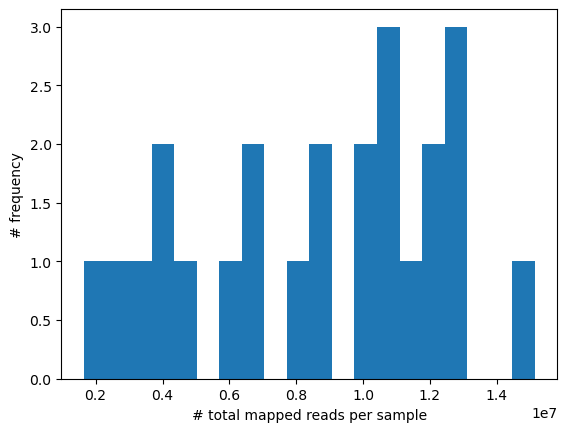

In [12]:
def mapped_read_distribution(df: pd.DataFrame):
    df_work = df.drop(labels = ['Chr', 'Start', 'End', 'Strand', 'Length', 'biotype'], axis = 1)
    mapped_reads = np.sum(df_work, axis = 0)
    plt.hist(mapped_reads, bins=20)
    plt.xlabel('# total mapped reads per sample')
    plt.ylabel('# frequency')

mapped_read_distribution(merged_df)

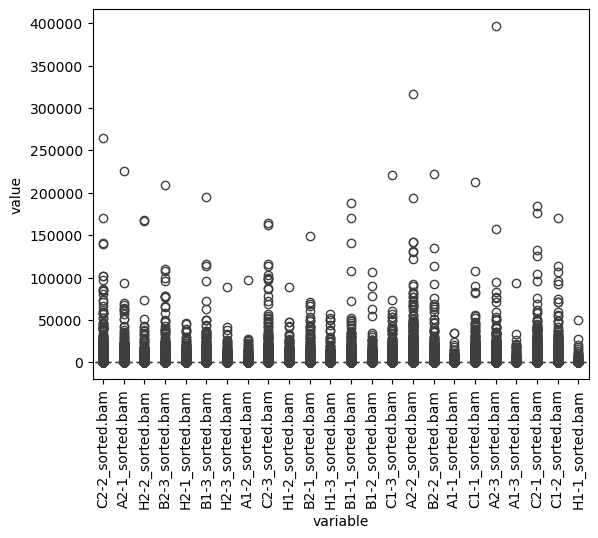

In [14]:
def per_sample_count_distribution(df: pd.DataFrame):
    df_work = df.drop(labels = ['Chr', 'Start', 'End', 'Strand', 'Length', 'biotype'], axis = 1)
    #df_work = df_work.transpose()
    df_work = pd.melt(df_work)

    sns.boxplot(data=df_work, x='variable', y='value')
    plt.xticks(rotation=90)

per_sample_count_distribution(merged_df)

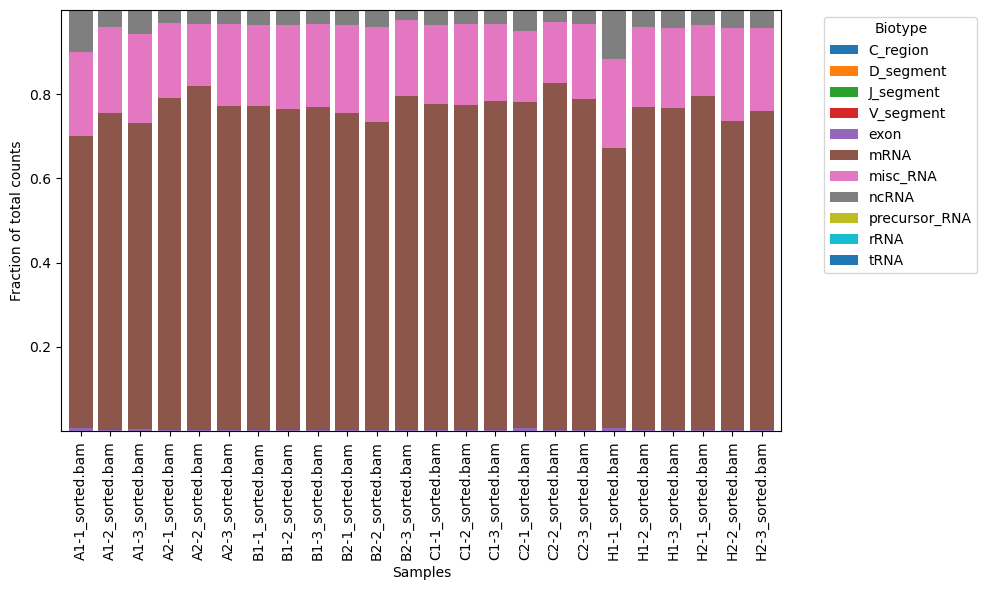

,A1-1_sorted.bam,A1-2_sorted.bam,A1-3_sorted.bam,A2-1_sorted.bam,A2-2_sorted.bam,A2-3_sorted.bam,B1-1_sorted.bam,B1-2_sorted.bam,B1-3_sorted.bam,B2-1_sorted.bam,...,C1-3_sorted.bam,C2-1_sorted.bam,C2-2_sorted.bam,C2-3_sorted.bam,H1-1_sorted.bam,H1-2_sorted.bam,H1-3_sorted.bam,H2-1_sorted.bam,H2-2_sorted.bam,H2-3_sorted.bam
biotype,,,,,,,,,,,,,,,,,,,,,
C_region,0.000089,8.087780e-06,0.000034,3.748600e-06,6.416420e-07,1.278334e-06,9.041561e-06,6.180613e-06,2.011435e-06,6.646090e-07,...,2.174261e-06,0.000017,3.442452e-07,2.987484e-06,0.000059,7.796425e-06,6.887620e-06,5.440989e-06,3.553920e-06,0.000007
D_segment,0.000029,1.102879e-06,0.000005,2.281757e-06,0.000000e+00,4.261112e-07,3.064936e-07,6.393738e-07,6.704782e-07,9.969136e-07,...,2.174261e-06,0.000000,0.000000e+00,9.958280e-07,0.000044,3.465078e-06,1.187521e-06,3.200582e-07,3.740968e-07,0.000005
J_segment,0.000006,7.352528e-07,0.000002,3.259652e-07,0.000000e+00,0.000000e+00,3.677923e-06,6.393738e-07,1.340956e-07,1.661523e-07,...,4.348522e-07,0.000000,0.000000e+00,0.000000e+00,0.000017,6.497021e-07,4.750083e-07,0.000000e+00,1.870484e-07,0.000002
V_segment,0.000348,4.337991e-05,0.000109,9.452991e-06,7.058062e-06,4.119075e-06,2.988312e-05,2.813245e-05,1.528690e-05,1.156420e-04,...,8.552093e-06,0.000066,5.852168e-06,8.187919e-06,0.000362,3.205197e-05,3.040053e-05,1.920349e-05,1.028766e-05,0.000045
exon,0.007256,3.386207e-03,0.004811,2.408557e-03,2.653648e-03,2.415056e-03,3.610648e-03,2.801949e-03,2.134668e-03,3.282172e-03,...,2.744352e-03,0.006792,2.862399e-03,2.288302e-03,0.007701,2.703194e-03,3.471835e-03,3.710114e-03,2.102237e-03,0.003719
mRNA,0.692199,7.527808e-01,0.726199,7.882077e-01,8.175138e-01,7.693570e-01,7.685914e-01,7.616410e-01,7.680305e-01,7.519443e-01,...,7.803163e-01,0.774705,8.230358e-01,7.851748e-01,0.663773,7.662430e-01,7.642076e-01,7.913813e-01,7.341816e-01,0.756231
misc_RNA,0.201397,2.027243e-01,0.211332,1.786177e-01,1.461032e-01,1.958631e-01,1.910546e-01,1.987967e-01,1.974196e-01,2.088059e-01,...,1.843689e-01,0.168860,1.456205e-01,1.795741e-01,0.212670,1.899623e-01,1.891815e-01,1.692058e-01,2.218467e-01,0.197489
ncRNA,0.096783,4.010914e-02,0.056420,2.905703e-02,3.174038e-02,3.047348e-02,3.607230e-02,3.576295e-02,3.163035e-02,3.458360e-02,...,3.156302e-02,0.048165,2.710828e-02,3.174921e-02,0.113167,3.984904e-02,4.202113e-02,3.397097e-02,4.049467e-02,0.040473
precursor_RNA,0.001390,8.925969e-04,0.000911,1.669920e-03,1.977174e-03,1.881849e-03,5.792729e-04,8.955496e-04,7.485219e-04,1.246142e-03,...,9.679810e-04,0.001263,1.353802e-03,1.192227e-03,0.001439,1.120086e-03,1.004642e-03,1.668143e-03,1.344317e-03,0.001960


In [15]:
def plot_biotype_fractions(counts_df, figsize=(10,6), top_n=None):
    """
    Create a stacked barplot showing the fractional contribution of gene biotypes
    to total counts in each sample.

    Parameters
    ----------
    counts_df : pd.DataFrame
    Counts table with genes as rows, samples as columns, and an additional
    column for gene biotypes.
    figsize : tuple
    Size of the matplotlib figure.
    top_n : int or None
    If set, only the top_n most abundant biotypes are shown explicitly,
    others are grouped into "Other".
    """
    # Drop unneccessary columns
    counts_df = counts_df.drop(labels = ['Chr', 'Start', 'End', 'Strand', 'Length'], axis = 1)

    # Separate counts and biotype annotation
    sample_cols = counts_df.columns.difference(['biotype'])
    biotypes = counts_df['biotype']

    # Sum counts by biotype per sample
    summed = counts_df.groupby(biotypes)[sample_cols].sum()

    # Convert to fractional contribution per sample
    fractions = summed.div(summed.sum(axis=0), axis=1)

    # Optionally collapse rare biotypes
    if top_n is not None and top_n < fractions.shape[0]:
        totals = fractions.sum(axis=1).sort_values(ascending=False)
        keep = totals.index[:top_n]
        others = totals.index[top_n:]

        fractions.loc["Other"] = fractions.loc[others].sum()
        fractions = fractions.loc[keep.tolist() + ["Other"]]

    # Plot stacked barplot
    ax = fractions.T.plot(kind="bar", stacked=True, figsize=figsize, width=0.8)
    ax.set_ylabel("Fraction of total counts")
    ax.set_xlabel("Samples")
    ax.legend(title="Biotype", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return fractions

plot_biotype_fractions(merged_df)

--> Major gene biotypes are misc_RNA, ncRNA, mRNA

#### Data Cleaning

In [16]:
# Perform in silico rRNA,... depletion

def biotype_selection(df: pd.DataFrame, RNA_categories: list):
    
    df = df.drop(labels = ['Chr', 'Start', 'End', 'Strand'], axis = 1)
    
    df_work = df.loc[df['biotype'].isin(RNA_categories)]
    
    return df_work

df_selected = biotype_selection(merged_df, ['mRNA', 'misc_RNA', 'ncRNA'])
df_selected.shape

(28466, 26)

In [17]:
# Select samples of interest

def rename_cols(df, meta):

    df_selected = df.drop(labels=['biotype', 'Length'], axis=1)
    sample_names = [a.split('_')[0] for a in df_selected.columns.tolist()]
    df_selected.columns = sample_names

    df_selected = df_selected[meta.loc[meta['Treatment'].isin(['DMSO', 'TMZ', 'AUF']), 'ID'] ]

    df_selected[['Length', 'biotype']] = df[['Length', 'biotype']]

    return df_selected

df_selected = rename_cols(df_selected, meta)

# Select samples with low counts

def remove_low_expressed_samples(df, threshold):
    
    df_work = df.drop(labels=['Length', 'biotype'], axis=1)
    samples = df_work.loc[:,np.sum(df_work, axis=0) > threshold].columns.tolist()

    all_cols = samples +['Length', 'biotype']

    return df[all_cols]

df_selected = remove_low_expressed_samples(df_selected, 1e6)
df_selected.head()

,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-1,C2-2,C2-3,H1-1,H1-2,H1-3,H2-1,H2-2,H2-3,Length,biotype
Gm26206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,110.0,ncRNA
Xkr4,29.0,19.0,13.0,2.0,10.0,2.0,6.0,23.0,12.0,23.0,7.0,9.0,84.0,30.0,20.0,7.0,6.0,5.0,14824.0,mRNA
Gm53491,20.0,19.0,10.0,5.0,5.0,0.0,9.0,18.0,7.0,28.0,0.0,10.0,45.0,9.0,18.0,4.0,1.0,1.0,24933.0,ncRNA
Rp1,23.0,19.0,10.0,4.0,10.0,7.0,12.0,16.0,7.0,50.0,11.0,9.0,68.0,30.0,13.0,7.0,7.0,16.0,12004.0,mRNA
Sox17,15.0,23.0,2.0,6.0,0.0,0.0,19.0,27.0,7.0,0.0,0.0,0.0,35.0,16.0,27.0,3.0,2.0,4.0,5692.0,mRNA


In [18]:
# Remove genes with low average expression

def remove_low_expressed_genes(df, threshold):
    
    df_work = df.drop(labels=['Length', 'biotype'], axis=1)
    genes = df_work.loc[np.mean(df_work, axis=1) > threshold].index.tolist() # mean > 3 --> expression above 10 in at least 42 samples

    return df.loc[genes]

df_selected = remove_low_expressed_genes(df_selected, 10)
df_selected

,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-1,C2-2,C2-3,H1-1,H1-2,H1-3,H2-1,H2-2,H2-3,Length,biotype
Xkr4,29.0,19.0,13.0,2.0,10.0,2.0,6.0,23.0,12.0,23.0,7.0,9.0,84.0,30.0,20.0,7.0,6.0,5.0,14824.0,mRNA
Gm53491,20.0,19.0,10.0,5.0,5.0,0.0,9.0,18.0,7.0,28.0,0.0,10.0,45.0,9.0,18.0,4.0,1.0,1.0,24933.0,ncRNA
Rp1,23.0,19.0,10.0,4.0,10.0,7.0,12.0,16.0,7.0,50.0,11.0,9.0,68.0,30.0,13.0,7.0,7.0,16.0,12004.0,mRNA
Sox17,15.0,23.0,2.0,6.0,0.0,0.0,19.0,27.0,7.0,0.0,0.0,0.0,35.0,16.0,27.0,3.0,2.0,4.0,5692.0,mRNA
Mrpl15,1422.0,906.0,1672.0,28.0,1213.0,1700.0,2563.0,1490.0,1964.0,2077.0,3660.0,3842.0,49.0,1173.0,1177.0,98.0,69.0,2.0,5105.0,misc_RNA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ccnb1,1418.0,465.0,1934.0,2060.0,0.0,0.0,916.0,1515.0,605.0,26.0,0.0,1.0,16.0,941.0,621.0,2.0,0.0,2.0,2316.0,mRNA
Slc30a5,1266.0,793.0,983.0,73.0,3076.0,1131.0,902.0,1539.0,1037.0,6.0,2.0,1438.0,137.0,686.0,706.0,514.0,1629.0,0.0,3249.0,misc_RNA
Pik3r1,1640.0,939.0,1696.0,8.0,30.0,5.0,2040.0,1141.0,1007.0,28.0,9.0,343.0,42.0,545.0,712.0,11.0,454.0,10.0,11472.0,mRNA
LOC118568082,4.0,34.0,189.0,2.0,3.0,0.0,108.0,1.0,35.0,0.0,8.0,0.0,74.0,9.0,7.0,1.0,549.0,6.0,9800.0,ncRNA


In [19]:
df_selected.value_counts('biotype')

biotype
mRNA        7536
misc_RNA    2838
ncRNA       1808
Name: count, dtype: int64

#### TPM normalization

In [20]:
# TPM normalization

def TPM(df, pse):
    """
    df: rRNA depleted input table
    meta: original dataframe including 'Length' column
    pse: pseudocount
    """
    
    lengths = df['Length']
    tpmData = df.drop(labels=['Length', 'biotype'], axis=1)

    for i in range(0,tpmData.shape[1]):
        rpk = (tpmData.iloc[:,i]+pse)/lengths
        scalingfactor = np.sum(rpk)/1000000
        tpm = rpk/scalingfactor

        tpmData.iloc[:,i] = tpm
    
    return tpmData

tpm_data = TPM(df_selected, 0.5)
tpm_data.head()

,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-1,C2-2,C2-3,H1-1,H1-2,H1-3,H2-1,H2-2,H2-3
Xkr4,0.569458,0.562072,0.256790,0.056977,0.161443,0.040066,0.103749,0.354906,0.218332,0.297643,0.078401,0.123630,13.601220,0.836235,0.600837,0.237083,0.172083,0.228188
Gm53491,0.235280,0.334182,0.118748,0.074527,0.050279,0.004764,0.090154,0.166115,0.077886,0.214617,0.003108,0.081242,4.354351,0.154861,0.322378,0.084575,0.023611,0.037001
Rp1,0.560205,0.694115,0.246646,0.126652,0.199370,0.148437,0.246389,0.307729,0.161774,0.789876,0.148457,0.152674,13.616050,1.032685,0.488625,0.292779,0.245203,0.845383
Sox17,0.779241,1.764109,0.123847,0.385812,0.020022,0.020869,0.810602,1.081629,0.341168,0.016493,0.013612,0.016946,14.881613,1.178184,2.099114,0.288143,0.172371,0.486232
Mrpl15,79.737347,75.874287,92.380505,1.886148,54.180191,79.138291,118.816184,65.365218,99.638874,76.408019,111.114877,145.206026,23.136412,93.428915,100.215150,9.041592,5.342927,0.301190


In [21]:
# Final tpm data

final_tpm = tpm_data

#### Log normalization of tpm data

In [22]:
final_log = np.log2(final_tpm+1)
final_log.head()

,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-1,C2-2,C2-3,H1-1,H1-2,H1-3,H2-1,H2-2,H2-3
Xkr4,0.650267,0.643461,0.329744,0.079944,0.215919,0.056676,0.142413,0.438192,0.284907,0.375894,0.108894,0.168167,3.868017,0.876751,0.678826,0.306942,0.229075,0.296532
Gm53491,0.304838,0.415955,0.161885,0.103702,0.070772,0.006857,0.124533,0.221710,0.108205,0.280501,0.004476,0.112690,2.420712,0.207720,0.403135,0.117130,0.033667,0.052417
Rp1,0.641736,0.760531,0.318051,0.172042,0.262277,0.199671,0.317755,0.387064,0.216329,0.839860,0.199696,0.204984,3.869482,1.023387,0.573981,0.370475,0.316381,0.883921
Sox17,0.831262,1.466815,0.168445,0.470731,0.028600,0.029798,0.856470,1.057713,0.423490,0.023600,0.019506,0.024243,3.989286,1.123126,1.631856,0.365292,0.229430,0.571659
Mrpl15,6.335164,6.264429,6.545049,1.529145,5.786079,6.324420,6.904679,6.052355,6.653044,6.274411,6.808834,7.191859,4.593139,6.561157,6.661281,3.327916,2.665149,0.379831


#### Extract raw data (important for DESeq2 analysis later on)

In [23]:
df_raw = df_selected.drop(labels=['biotype', 'Length'], axis=1)
df_raw.head()

,B1-1,B1-2,B1-3,B2-1,B2-2,B2-3,C1-1,C1-2,C1-3,C2-1,C2-2,C2-3,H1-1,H1-2,H1-3,H2-1,H2-2,H2-3
Xkr4,29.0,19.0,13.0,2.0,10.0,2.0,6.0,23.0,12.0,23.0,7.0,9.0,84.0,30.0,20.0,7.0,6.0,5.0
Gm53491,20.0,19.0,10.0,5.0,5.0,0.0,9.0,18.0,7.0,28.0,0.0,10.0,45.0,9.0,18.0,4.0,1.0,1.0
Rp1,23.0,19.0,10.0,4.0,10.0,7.0,12.0,16.0,7.0,50.0,11.0,9.0,68.0,30.0,13.0,7.0,7.0,16.0
Sox17,15.0,23.0,2.0,6.0,0.0,0.0,19.0,27.0,7.0,0.0,0.0,0.0,35.0,16.0,27.0,3.0,2.0,4.0
Mrpl15,1422.0,906.0,1672.0,28.0,1213.0,1700.0,2563.0,1490.0,1964.0,2077.0,3660.0,3842.0,49.0,1173.0,1177.0,98.0,69.0,2.0


#### Save data with the two low expression samples removed

In [24]:
df_raw.to_csv('Raw_countData.csv')
final_tpm.to_csv('TPM_normalized_countData.csv')
final_log.to_csv('Log2_normalized_countData.csv')

## Visualizing processed data

In [31]:
# Visualization by sample type(s)

def clusterTypes(df, metadata, feature):

    df = df.transpose()
    
    metadata.index = metadata['ID']
    metaData_final = metadata.loc[df.index.tolist()]

    fig, axs = plt.subplots(1,2, figsize=(10,5))
    # plt.subplots_adjust(hspace=0.15)
    plt.suptitle(f"Analysis of bulk data, colored by {feature}", fontweight = 'bold', fontsize = 'x-large')
    plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.9, wspace=0.45,hspace=0.4)

    pca = PCA(n_components = 2)
    components = pca.fit_transform(df)
    
    labels = metaData_final[feature]
    X = pd.DataFrame(pd.concat([pd.DataFrame(components, index=metaData_final.index.to_list()), pd.DataFrame(labels, index=metaData_final.index.to_list())], axis = 1, ignore_index=False))
    X.columns = ["Dim1", "Dim2", str(feature)]
    sns.scatterplot(ax = axs[0], x = "Dim1", y = "Dim2", data = X, hue = str(feature), legend = False, size = 0.5)
    #sns.move_legend(axs[0,0], "upper left", bbox_to_anchor=(1, 1))
    axs[0].set_title('PCA')

    u = TSNE(n_components = 2, learning_rate = 'auto', init = 'random', perplexity = 10).fit_transform(df)
    labels = metaData_final[feature]
    X = pd.DataFrame(pd.concat([pd.DataFrame(u, index=metaData_final.index.to_list()), pd.DataFrame(labels, index=metaData_final.index.to_list())], axis = 1, ignore_index=False))
    X.columns = ["Dim1", "Dim2", str(feature)]
    sns.scatterplot(ax = axs[1], x = "Dim1", y = "Dim2", data = X, hue = str(feature), size = 0.5)
    sns.move_legend(axs[1], "upper left", bbox_to_anchor=(1, 1), ncol = 4, title = 'Sample annotation')
    axs[1].set_title('t-SNE')

Cluster by cell_state (healthy, glioma)

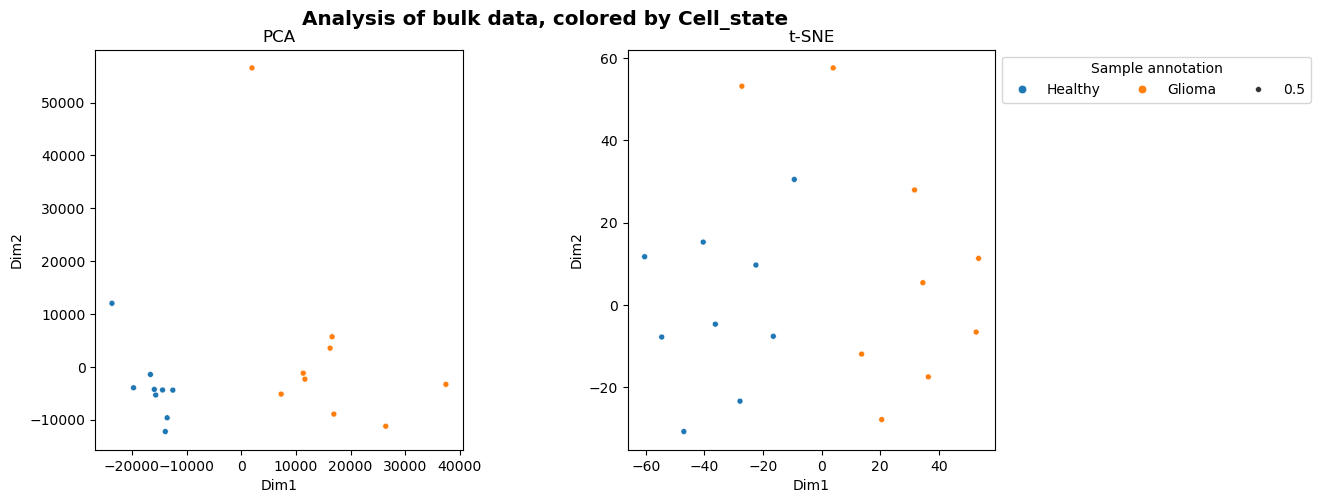

In [32]:
clusterTypes(tpm_data, meta, 'Cell_state')

Cluster by Treatment

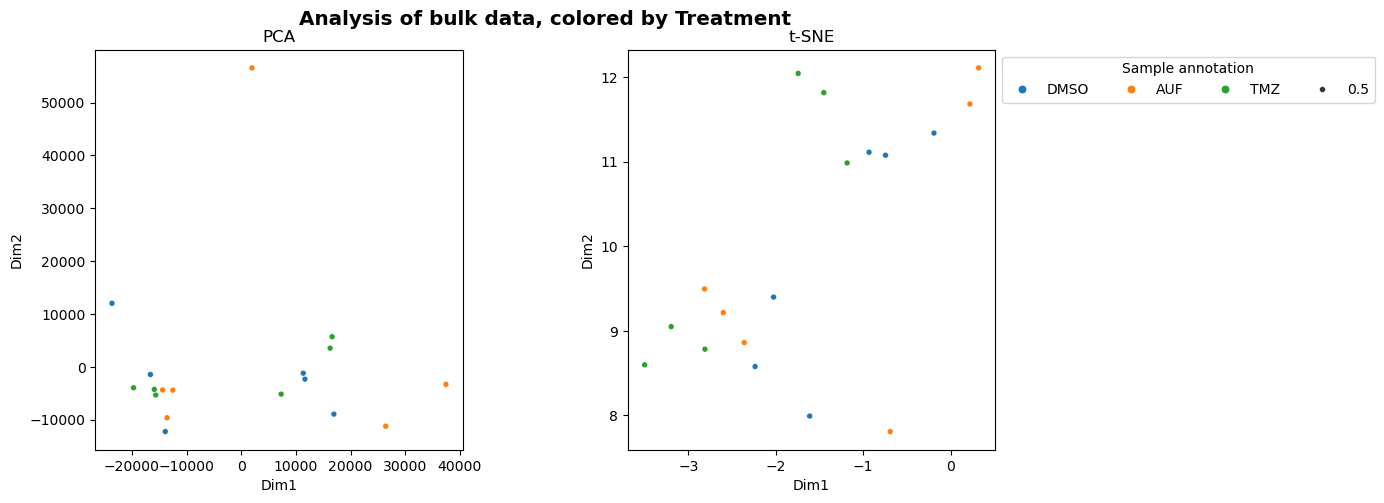

In [33]:
clusterTypes(tpm_data, meta, 'Treatment')

#### Detect and mark outliers based on unsupervised learning using plotly

In [34]:
def cluster_outliers(df, metadata, feature):

    df = df.transpose()
    
    metaData_final = metadata.loc[df.index.tolist()]

    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.express as px

    pca = PCA(n_components = 2)
    components = pca.fit_transform(df)
    
    labels = metaData_final[feature]
    X = pd.DataFrame(pd.concat([pd.DataFrame(components, index=metaData_final.index.to_list()), pd.DataFrame(labels, index=metaData_final.index.to_list())], axis = 1, ignore_index=False))
    X.columns = ["Dim1", "Dim2", str(feature)]
    X['color'] = X[str(feature)].apply(lambda x: 1 if x=='Healhy' else (2 if x=='Glioma' else 3))
    fig = go.Figure()
    fig.add_trace(go.Scatter(
                    x=X["Dim1"],
                    y=X["Dim2"],
                    mode="markers",
                    marker = dict(color = X['color']),
                    text=X.index.tolist()
    ))
    fig.update_layout(
        width=1000,  # Set width to 1000 pixels
        height=1000, # Set height to 1000 pixels
        autosize=False, # Disable autosize to maintain fixed dimensions
        template='plotly_white',
        #plot_bgcolor='rgba(0, 0, 0, 0)',
        #paper_bgcolor='rgba(0, 0, 0, 0)',
    )
    fig.show()

In [35]:
cluster_outliers(final_tpm, meta, 'Cell_state')

In [36]:
cluster_outliers(final_log, meta, 'Cell_state')

#### Calculate clustermaps to include further sample information including treatment

##### Clustermaps per specific conditions

In [37]:
def clustermap_treatment_by_state(data, genes, metadata, cell_state, norm):

    # Format data
    if genes == 'all':
        data_selected = data
    elif isinstance(genes, list):
        data_selected = data.loc[genes] # subset bulk data

    data_selected = data_selected.reindex(sorted(data_selected.columns), axis=1)
    metadata.index = metadata['ID']
    metadata = metadata.loc[data_selected.columns.tolist()]
    metadata = metadata.loc[metadata['Cell_state'] == cell_state]
    selected_samples = list(metadata['ID'])
    data_selected = data_selected[selected_samples]

    # Define annotation metadata for columns
    treatment = pd.Series(metadata['Treatment'], index=data_selected.columns, name="Treatment")

    # Map categories to colors
    lut_treat = dict(zip(treatment.unique(), sns.color_palette("Set1", n_colors=treatment.nunique())))

    # Convert categories to colors
    treatment_colors = treatment.map(lut_treat)

    # Combine into a DataFrame (order matters = stacked rows)
    col_colors = pd.Series(treatment_colors, index=data_selected.columns)

    # Create clustermap
    if norm == 'z-score':
        g = sns.clustermap(
            data_selected,
            col_cluster=False,
            row_cluster=True,
            cmap="viridis",
            figsize=(14, 6),
            z_score=0,
            col_colors=col_colors,
        )
    else:
        g = sns.clustermap(
            data_selected,
            col_cluster=False,
            row_cluster=True,
            cmap="viridis",
            figsize=(14, 6),
            col_colors=col_colors,
        )

    # Add legends
    for label in lut_treat:
        g.ax_col_dendrogram.bar(0, 0, color=lut_treat[label], label=f"Treatment: {label}", linewidth=0)
    g.ax_col_dendrogram.legend(loc="center", ncol=2)

    # ---- Add text labels above col_colors ----
    for i, row_label in enumerate(col_colors.index):
        g.ax_col_dendrogram.text(
            -0.02,                                  # X position (slightly to the left)
            (i + 0.5) / len(col_colors.index),      # Y position (centered on row)
            row_label,
            va='center',
            ha='right',
            fontsize=10,
            transform=g.ax_col_dendrogram.transAxes
        )
        
    plt.title(f"Treatment-specific expression for {cell_state}")

    return g

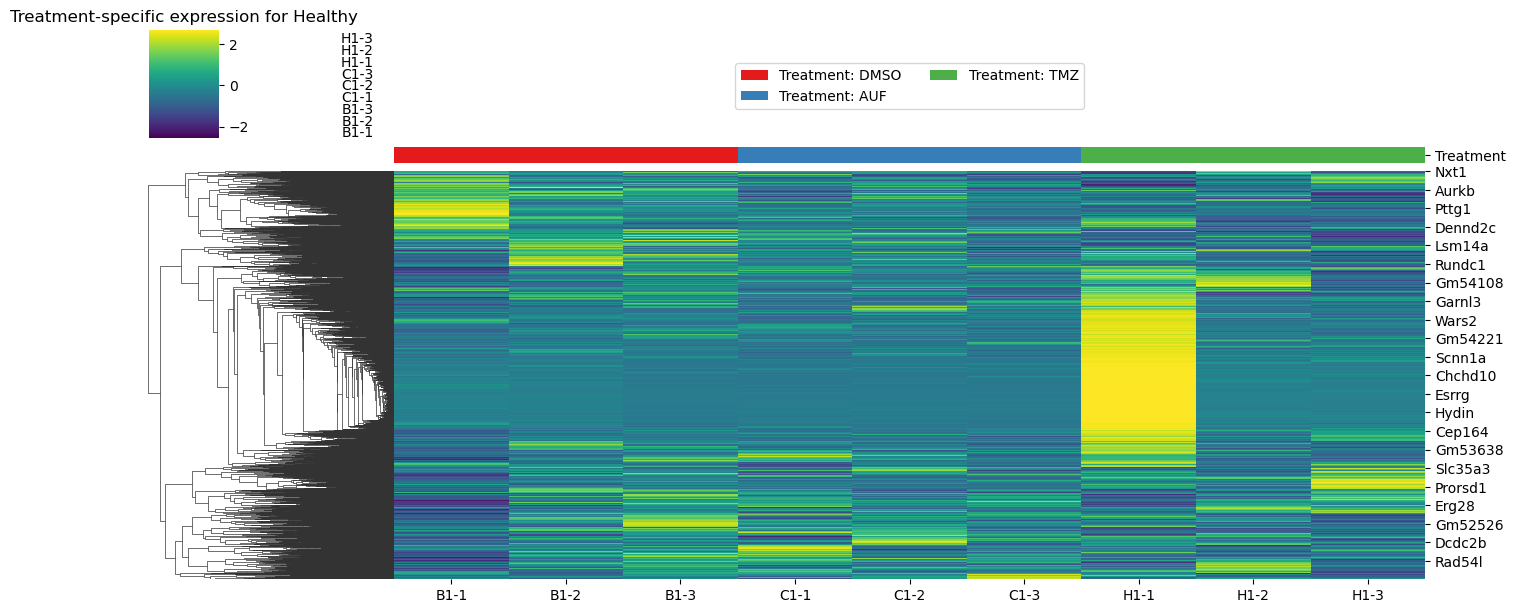

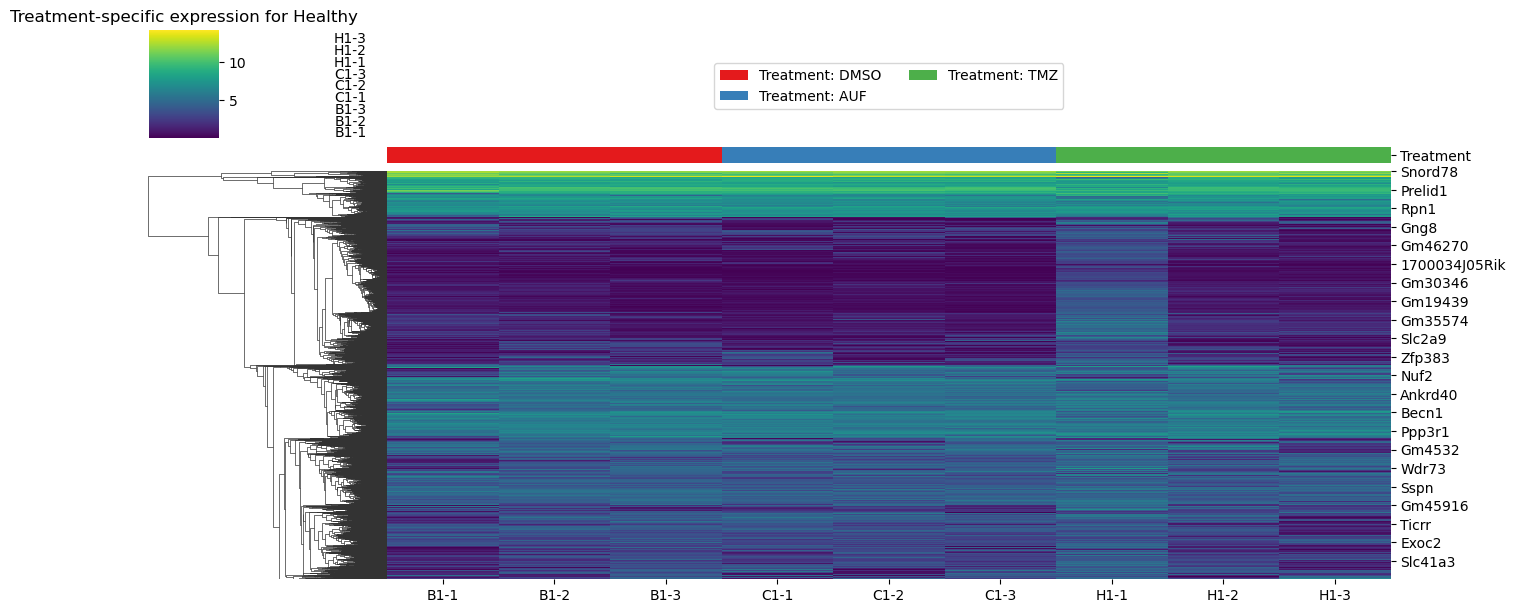

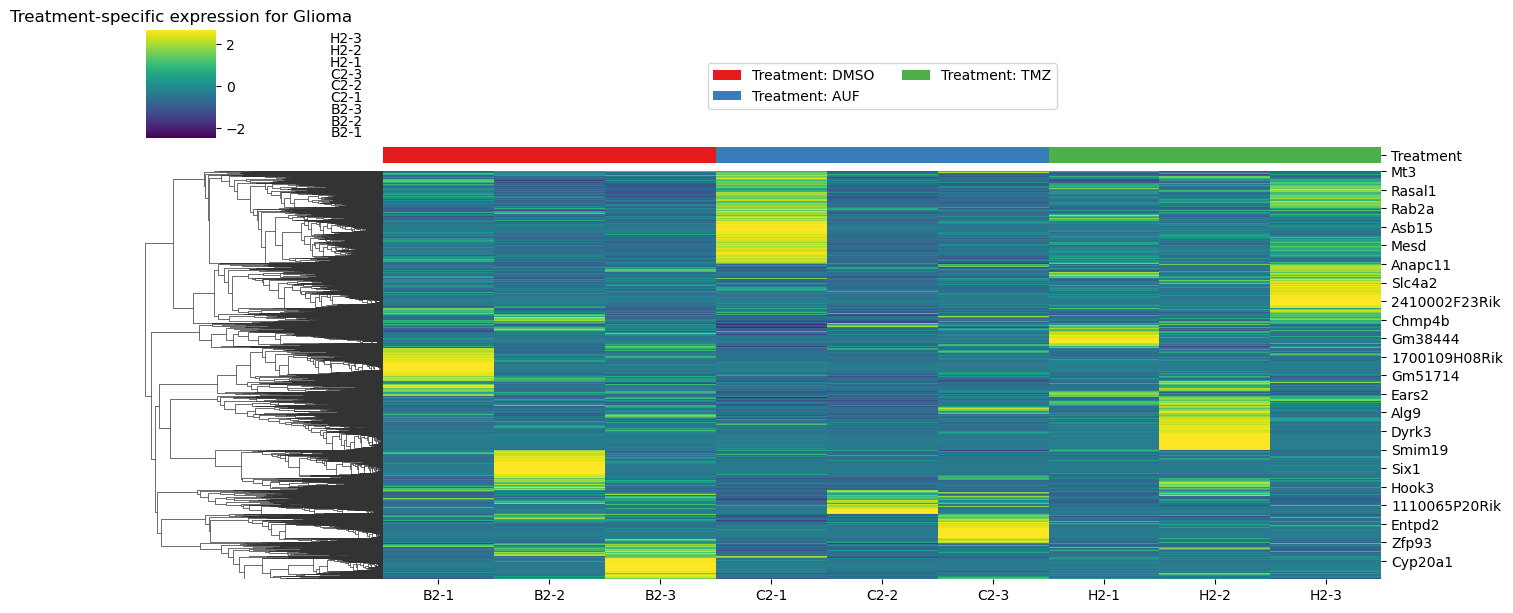

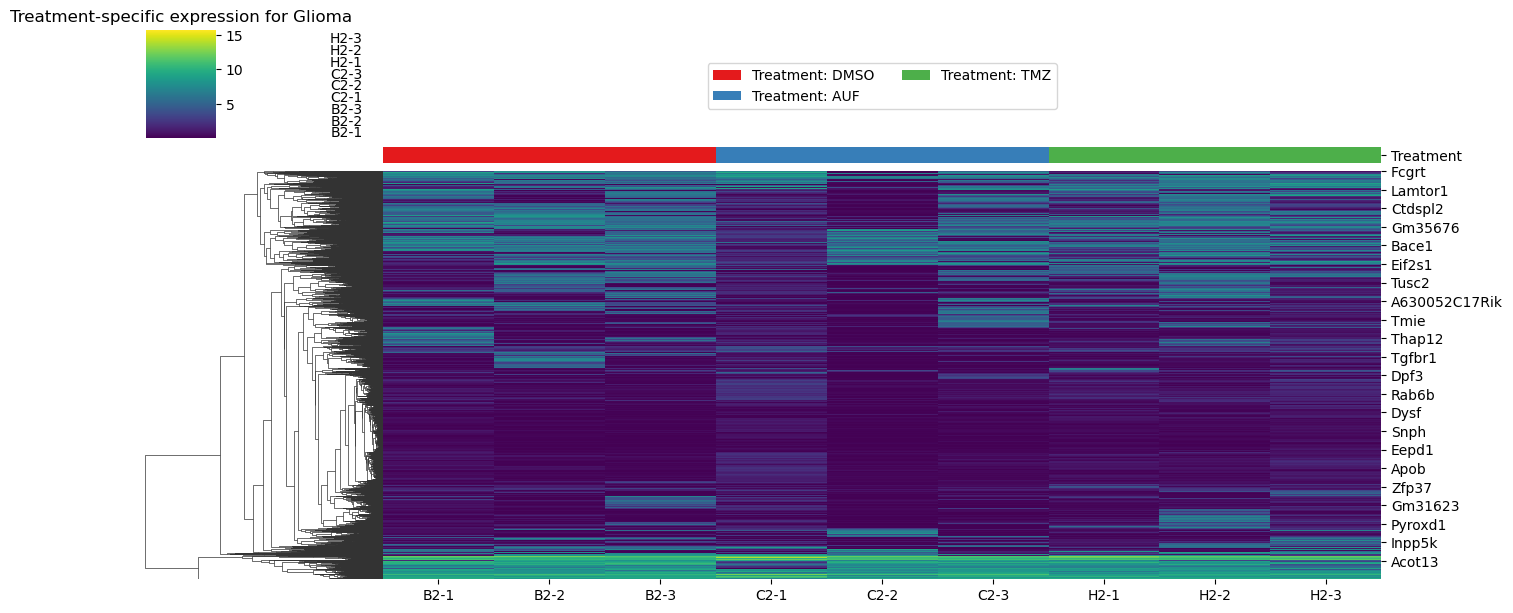

In [38]:
for origin in ['Healthy', 'Glioma']:
    clustermap_treatment_by_state(final_tpm, 'all', meta, origin, 'z-score')
    clustermap_treatment_by_state(final_log, 'all', meta, origin, None)

Use interactive plotly scatterplot:

In [39]:
def cluster_outliers(df, metadata, feature):

    df = df.transpose()

    metadata.index = metadata['ID']
    metaData_final = metadata.loc[df.index.tolist()]

    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.express as px

    pca = PCA(n_components = 2)
    components = pca.fit_transform(df)
    
    labels = metaData_final[feature]
    X = pd.DataFrame(pd.concat([pd.DataFrame(components, index=metaData_final.index.to_list()), pd.DataFrame(labels, index=metaData_final.index.to_list())], axis = 1, ignore_index=False))
    X.columns = ["Dim1", "Dim2", str(feature)]
    X['color'] = X[str(feature)].apply(lambda x: 1 if x=='Healhy' else (2 if x=='Glioma' else 3))
    fig = go.Figure()
    fig.add_trace(go.Scatter(
                    x=X["Dim1"],
                    y=X["Dim2"],
                    mode="markers",
                    marker = dict(color = X['color']),
                    text=X.index.tolist()
    ))
    fig.update_layout(
        width=1000,  # Set width to 1000 pixels
        height=1000, # Set height to 1000 pixels
        autosize=False, # Disable autosize to maintain fixed dimensions
        template='plotly_white',
        #plot_bgcolor='rgba(0, 0, 0, 0)',
        #paper_bgcolor='rgba(0, 0, 0, 0)',
    )
    fig.show()

In [40]:
cluster_outliers(final_tpm, meta, 'Cell_state')

In [41]:
cluster_outliers(final_log, meta, 'Cell_state')

### Export data with outliers dropped

In [42]:
final_tpms_red = final_tpm.drop(labels=["C2-1", "H1-1"], axis=1)
final_logs_red = final_log.drop(labels=["C2-1", "H1-1"], axis=1)
final_raw_red = df_raw.drop(labels=["C2-1", "H1-1"], axis=1)

final_raw_red.to_csv('Raw_countData_minus_outliers.csv')
final_tpms_red.to_csv('TPM_normalized_countData_minus_outliers.csv')
final_logs_red.to_csv('Log2_normalized_countData_minus_outliers.csv')

In [43]:
cluster_outliers(final_logs_red, meta, 'Cell_state')

In [44]:
cluster_outliers(final_tpms_red, meta, 'Cell_state')

In [45]:
# Clustermap function

def clustermap_summarized(data, metadata, cell_state, norm):

    # Select samples and adjust metadata and data 
    data_selected = data.reindex(sorted(data.columns), axis=1)
    meta_test = metadata.loc[data_selected.columns.tolist()]
    meta_test = meta_test.loc[meta_test['Cell_state'] == cell_state]
    selected_samples = list(meta_test['ID'])
    data_selected = data_selected[selected_samples]

    # Add extra column to metadata
    meta_test['Comb'] = meta_test['Cell_state'] + '_' + meta_test['Treatment']
    
    # Sample dictionary
    sample_dict = (
        meta_test.groupby("Comb")["ID"]
        .apply(list)
        .to_dict()
    )

    # Use the sample_dict to summarize profiles
    tpm_means = {}
    for key in sample_dict.keys():
        samples = sample_dict[key]
        tpm_mean = np.mean(data_selected[samples], axis = 1)
        tpm_means[key] = tpm_mean

    mean_tpm_data = pd.DataFrame(tpm_means, index=data_selected.index.tolist())


    # Create clustermap
    if norm == 'z-score':
        g = sns.clustermap(
            mean_tpm_data,
            col_cluster=True,
            row_cluster=True,
            cmap="viridis",
            figsize=(14, 6),
            z_score=0,
        )
    else:
        g = sns.clustermap(
            mean_tpm_data,
            col_cluster=True,
            row_cluster=True,
            cmap="viridis",
            figsize=(14, 6),
        )
        
    plt.title(f"Treatment-specific expression for {cell_state}")

    return g

In [46]:
# Clustermap function
def clustermap_summarized_median(data, metadata, cell_state, norm):

    # Select samples and adjust metadata and data 
    data_selected = data.reindex(sorted(data.columns), axis=1)
    meta_test = metadata.loc[data_selected.columns.tolist()]
    meta_test = meta_test.loc[meta_test['Cell_state'] == cell_state]
    selected_samples = list(meta_test['ID'])
    data_selected = data_selected[selected_samples]

    # Add extra column to metadata
    meta_test['Comb'] = meta_test['Cell_state'] + '_' + meta_test['Treatment']
    
    # Sample dictionary
    sample_dict = (
        meta_test.groupby("Comb")["ID"]
        .apply(list)
        .to_dict()
    )

    # Use the sample_dict to summarize profiles
    tpm_means = {}
    for key in sample_dict.keys():
        samples = sample_dict[key]
        tpm_mean = np.median(data_selected[samples], axis = 1)
        tpm_means[key] = tpm_mean

    mean_tpm_data = pd.DataFrame(tpm_means, index=data_selected.index.tolist())


    # Create clustermap
    if norm == 'z-score':
        g = sns.clustermap(
            mean_tpm_data,
            col_cluster=True,
            row_cluster=True,
            cmap="viridis",
            figsize=(14, 6),
            z_score=0,
        )
    else:
        g = sns.clustermap(
            mean_tpm_data,
            col_cluster=True,
            row_cluster=True,
            cmap="viridis",
            figsize=(14, 6),
        )
        
    plt.title(f"Treatment-specific expression for {cell_state}")

    return g

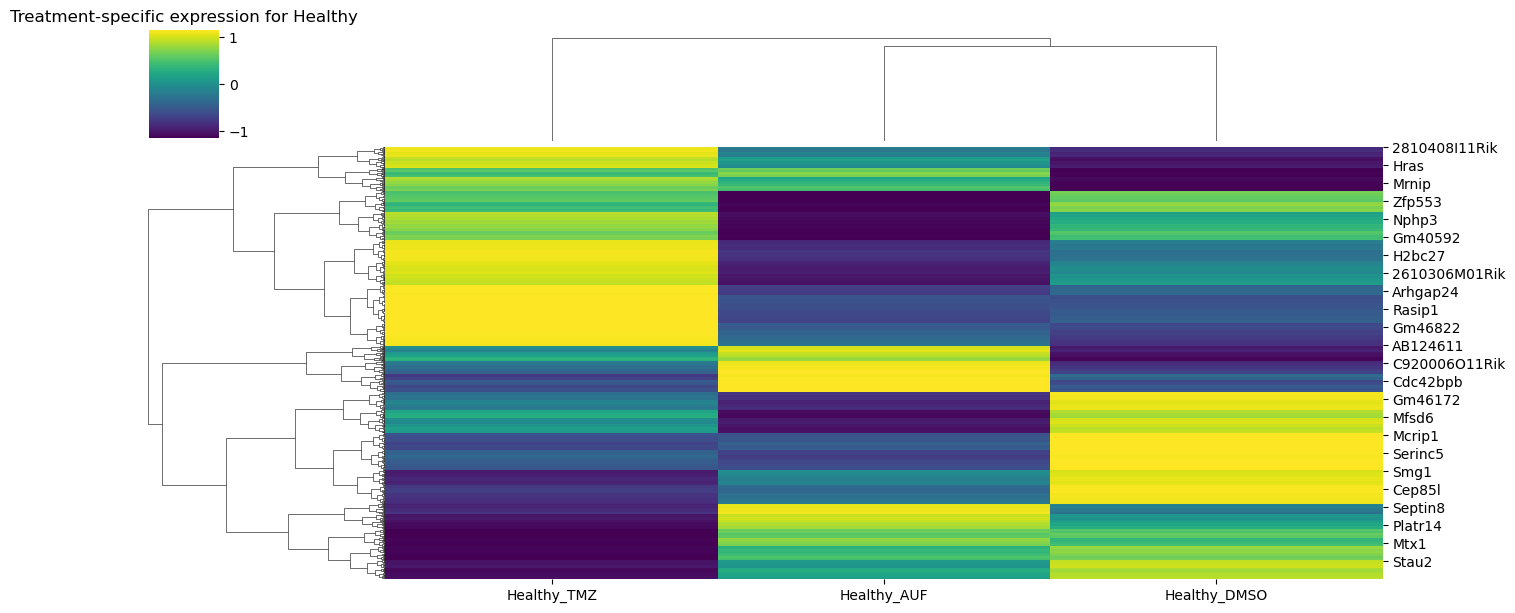

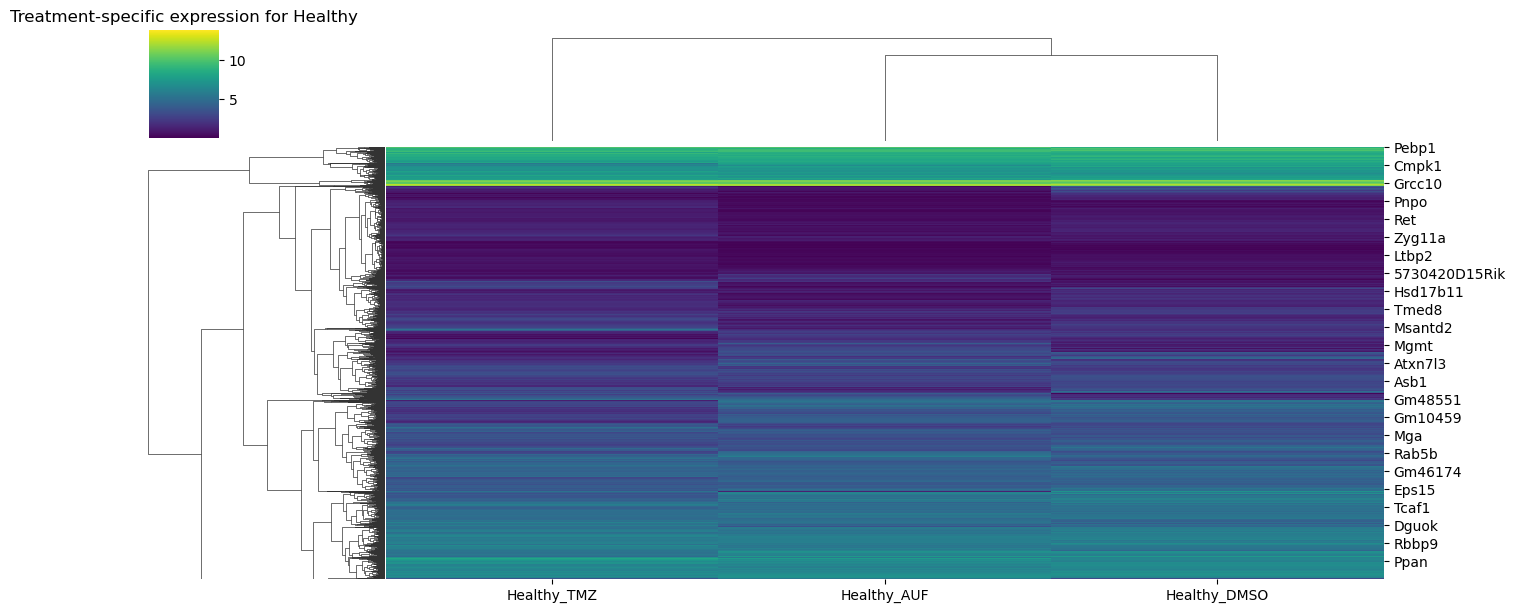

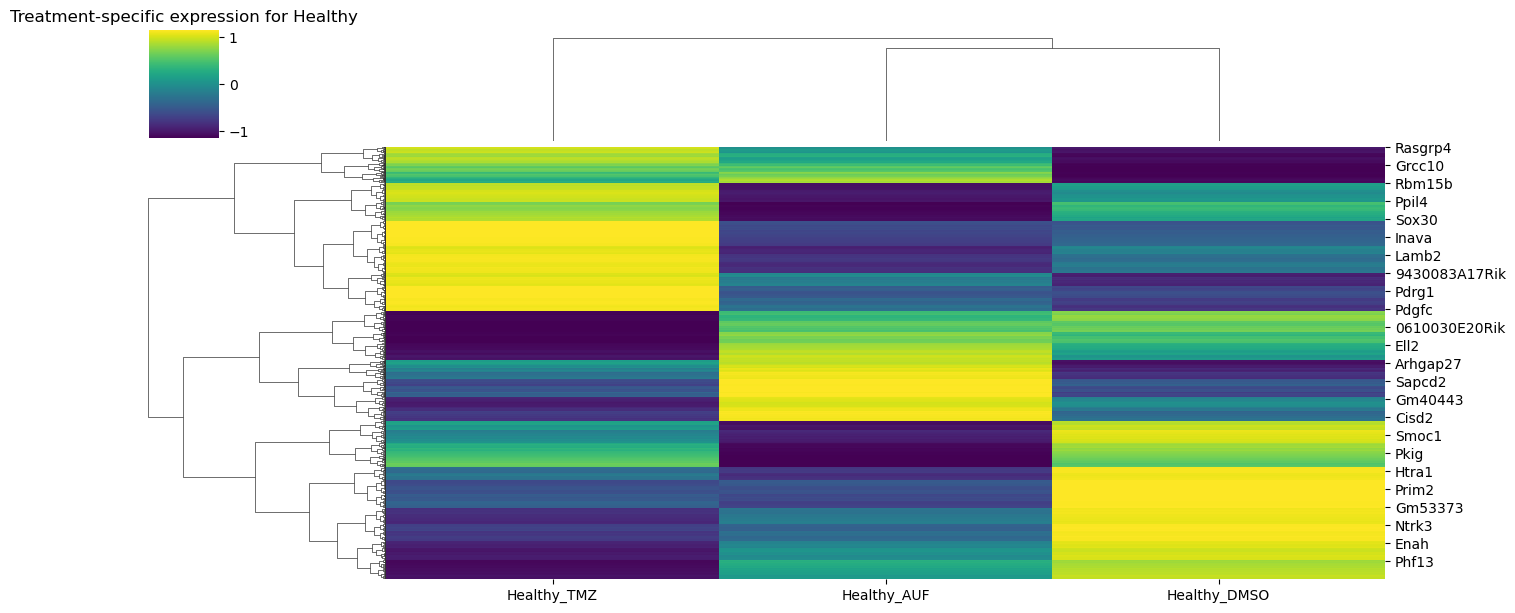

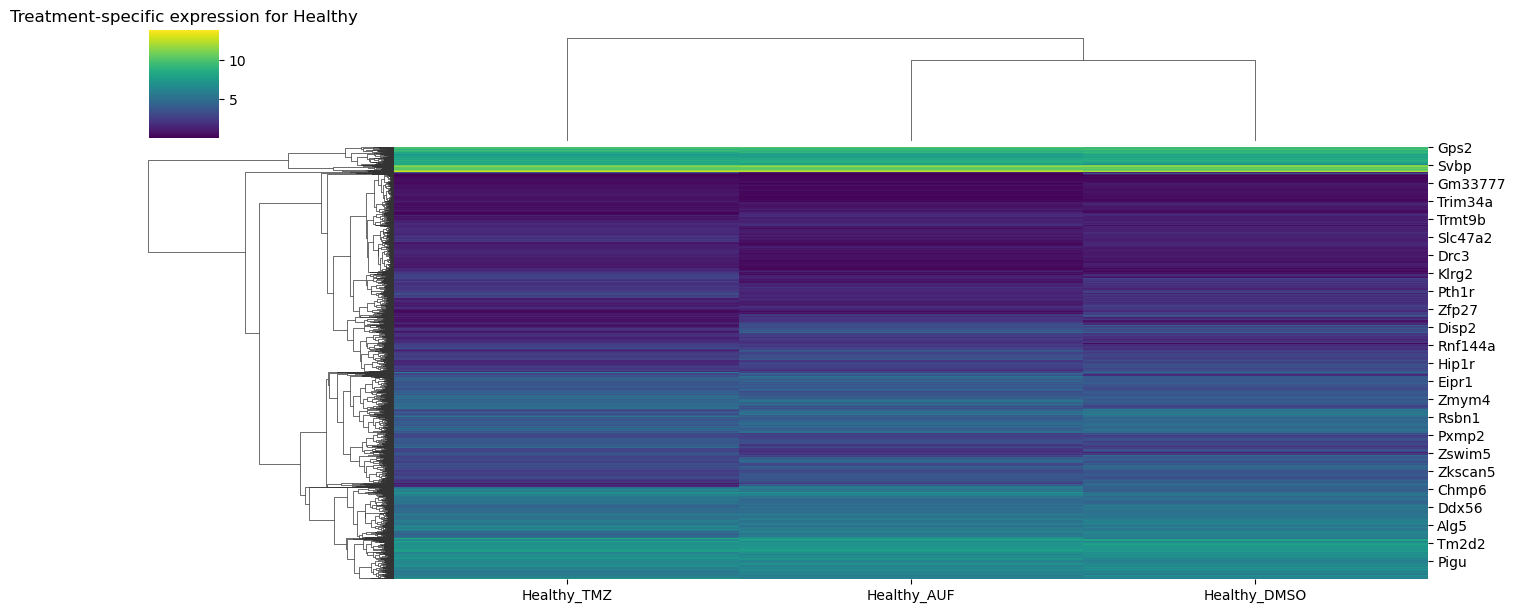

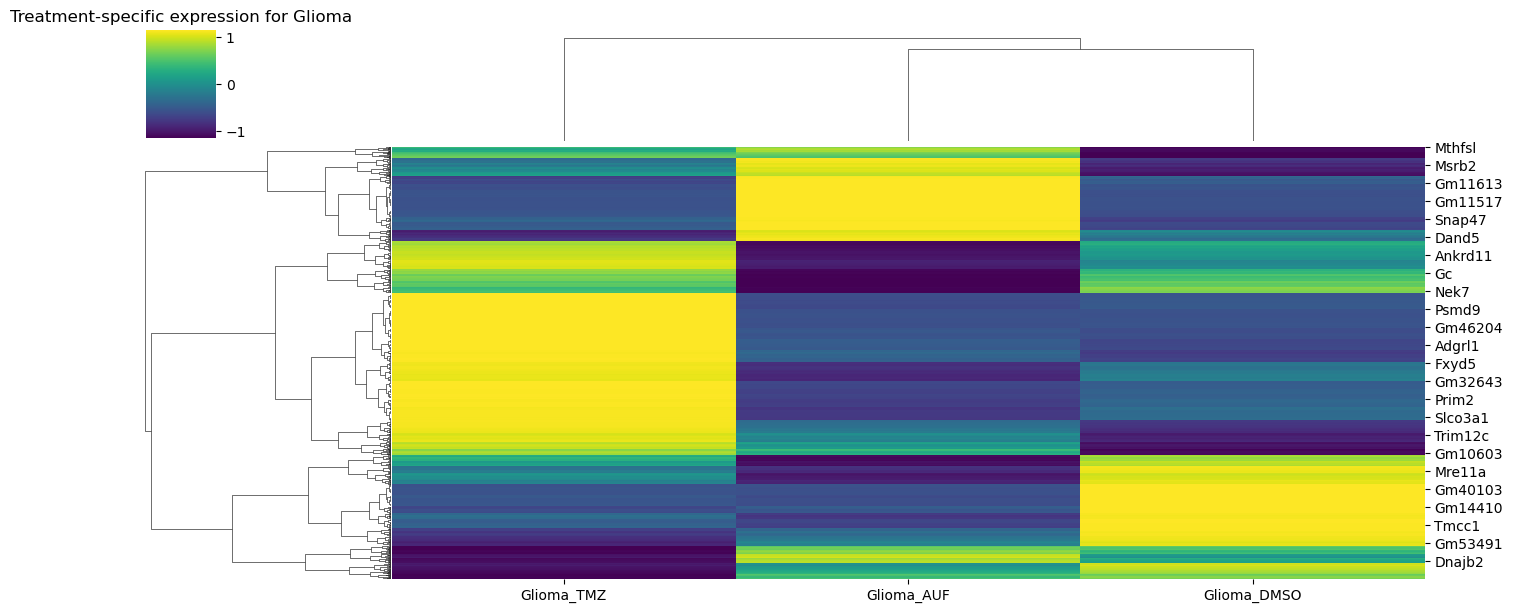

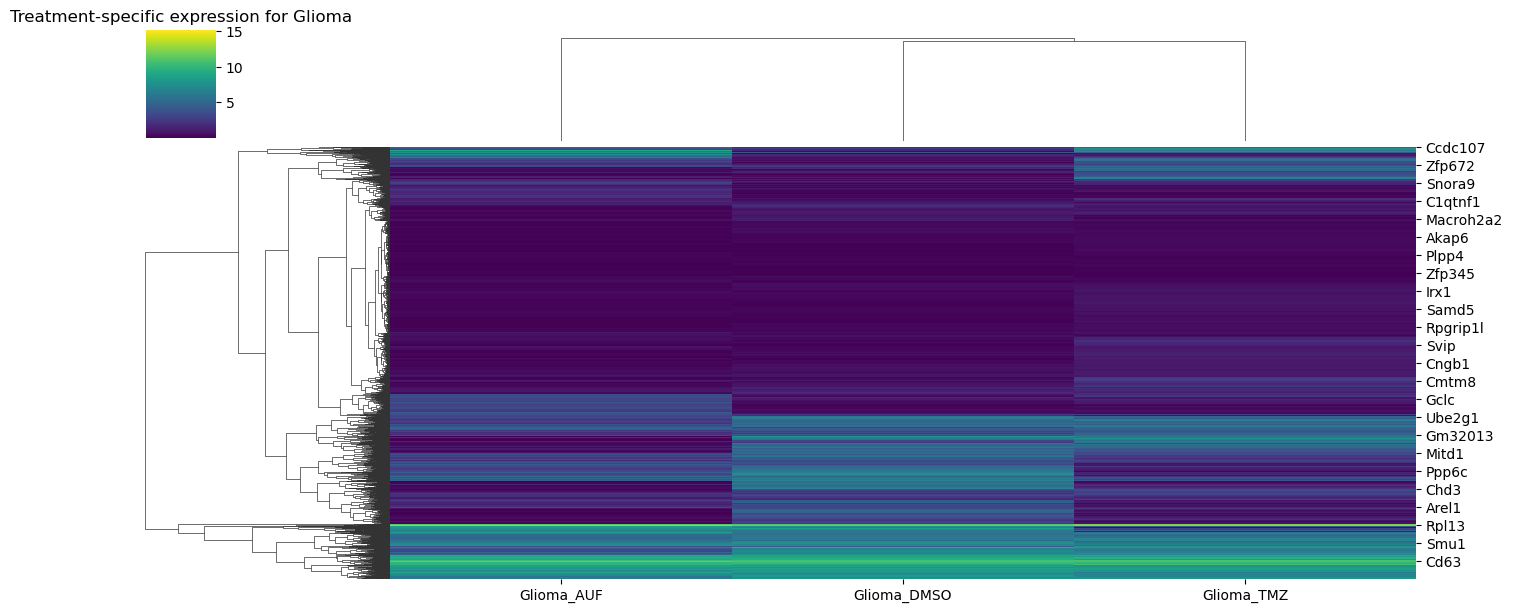

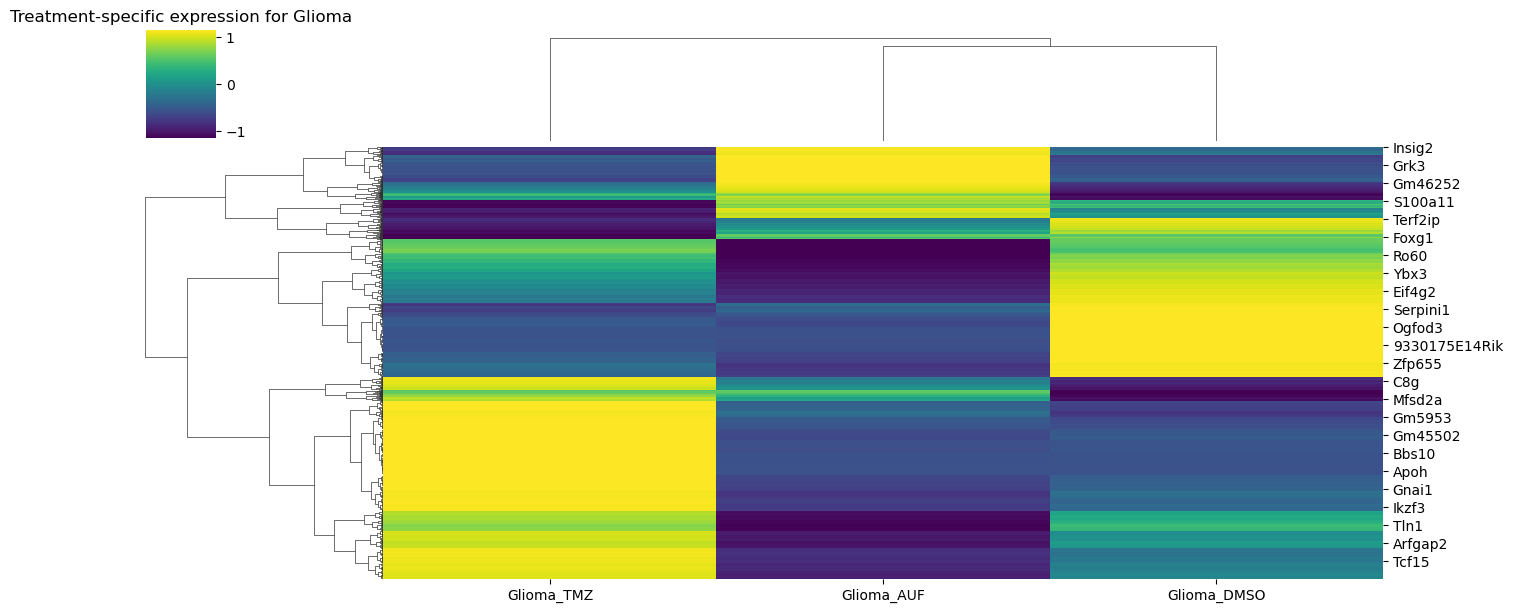

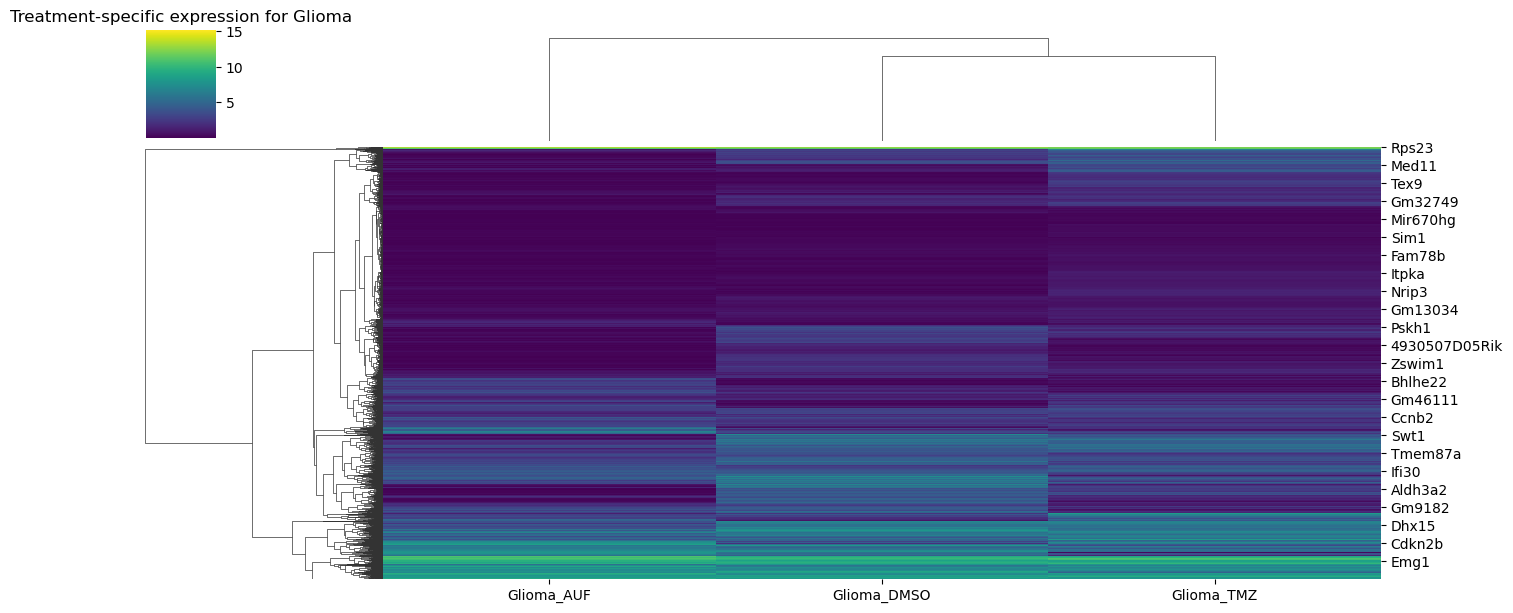

In [47]:
# Unfiltered data in (mRNAs only)
for origin in ['Healthy', 'Glioma']:
    clustermap_summarized_median(final_tpms_red, meta, origin, 'z-score')
    clustermap_summarized_median(final_logs_red, meta, origin, None)
    clustermap_summarized(final_tpms_red, meta, origin, 'z-score')
    clustermap_summarized(final_logs_red, meta, origin, None)

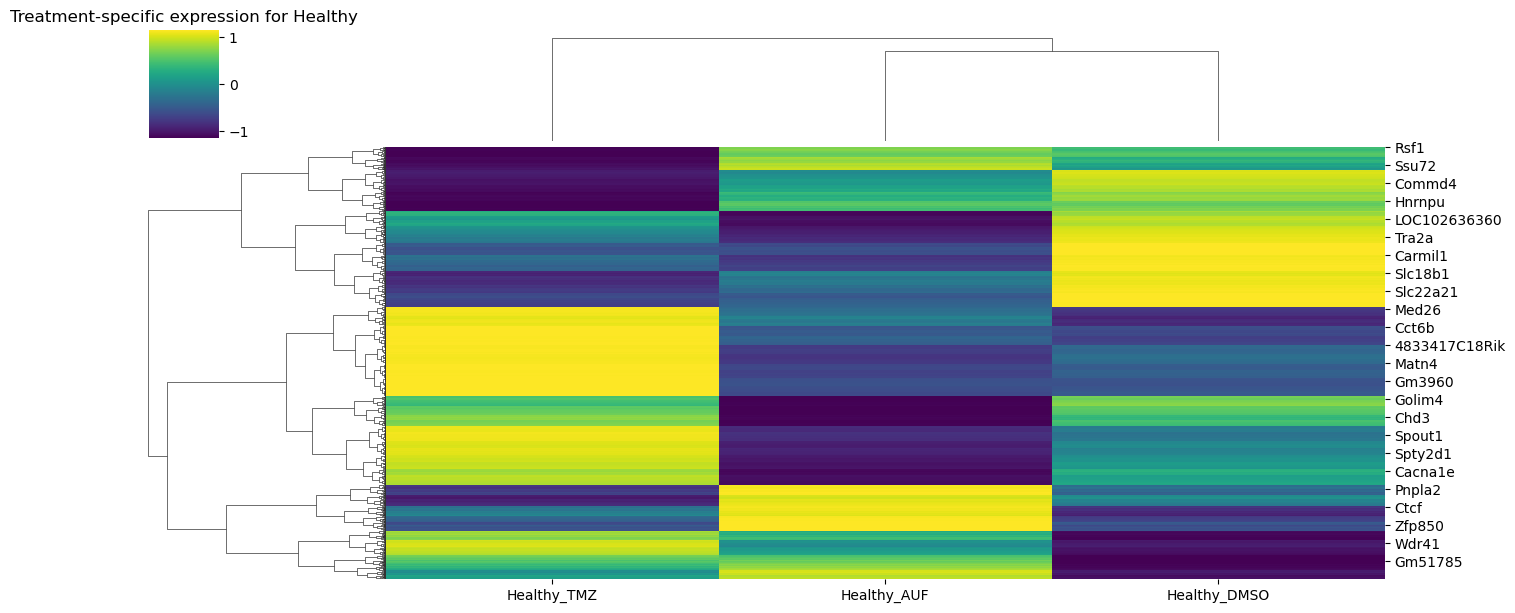

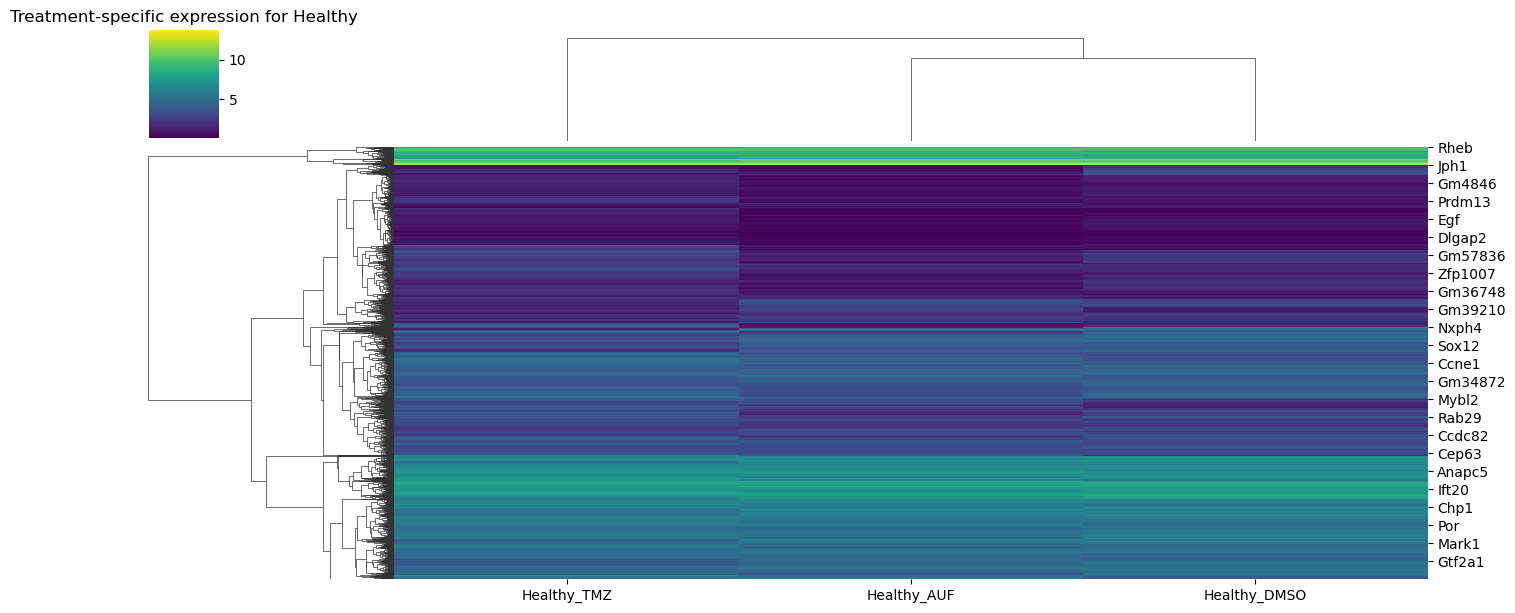

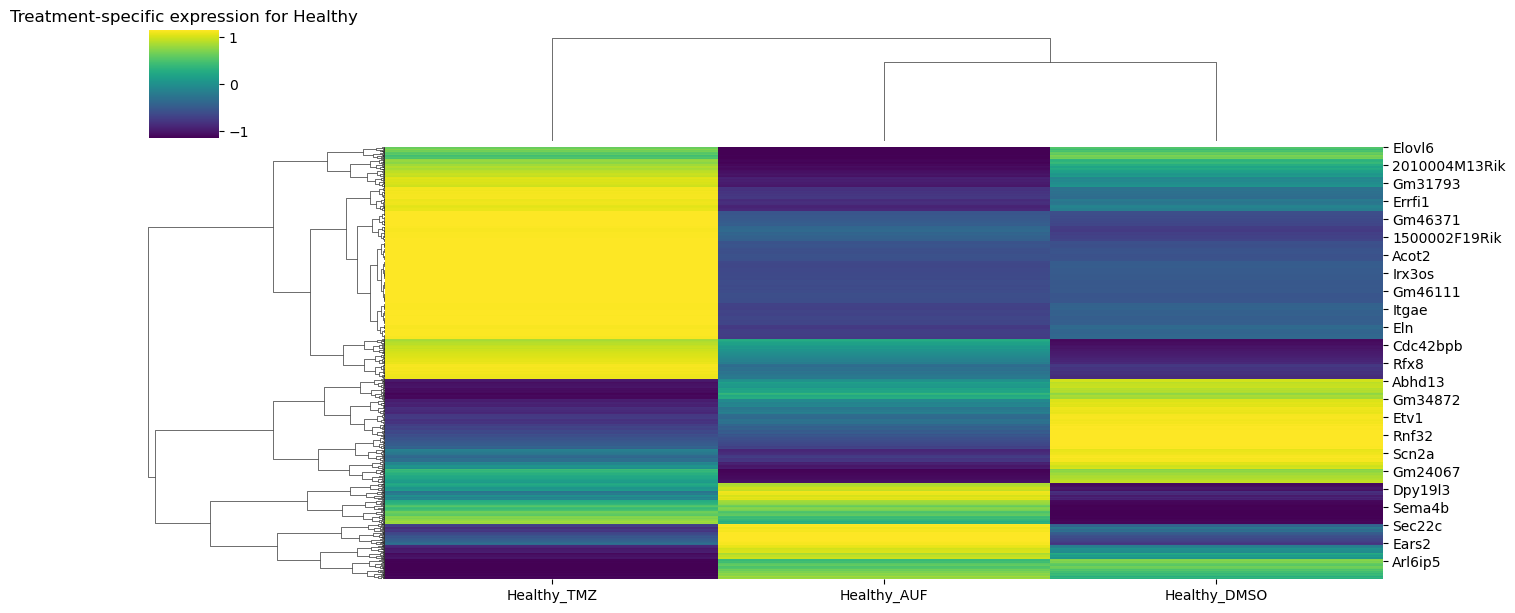

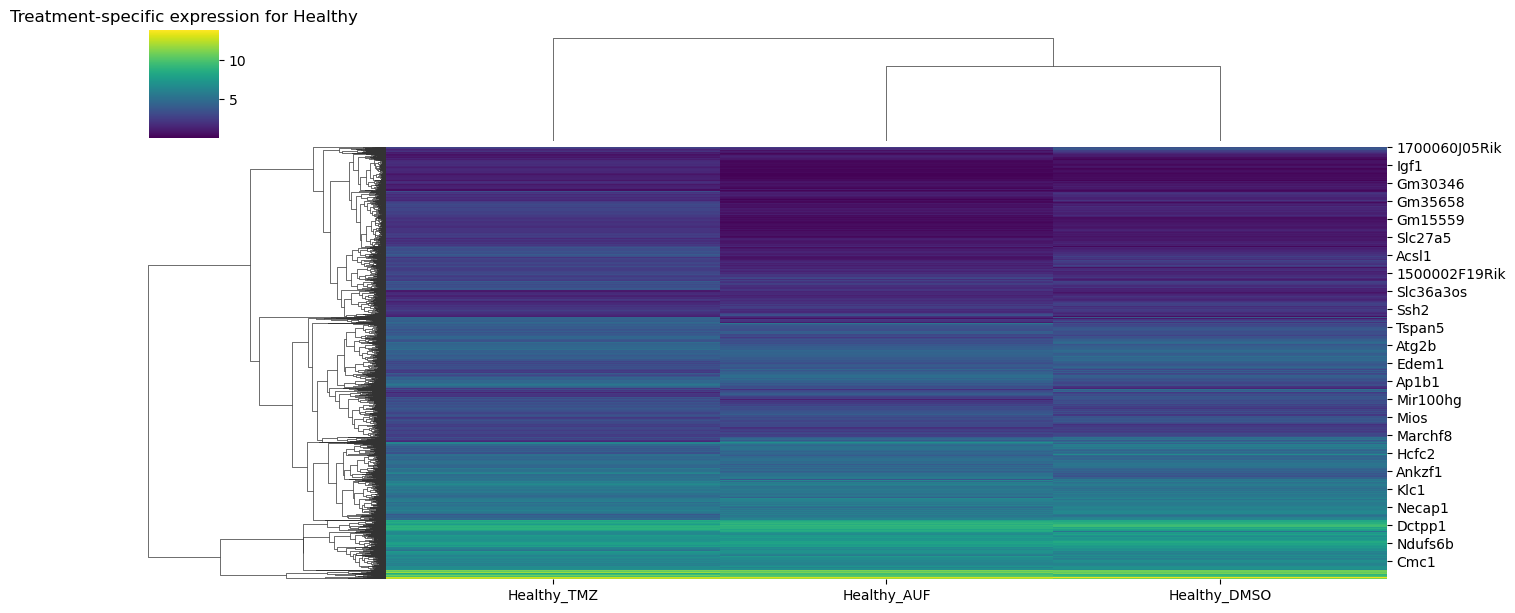

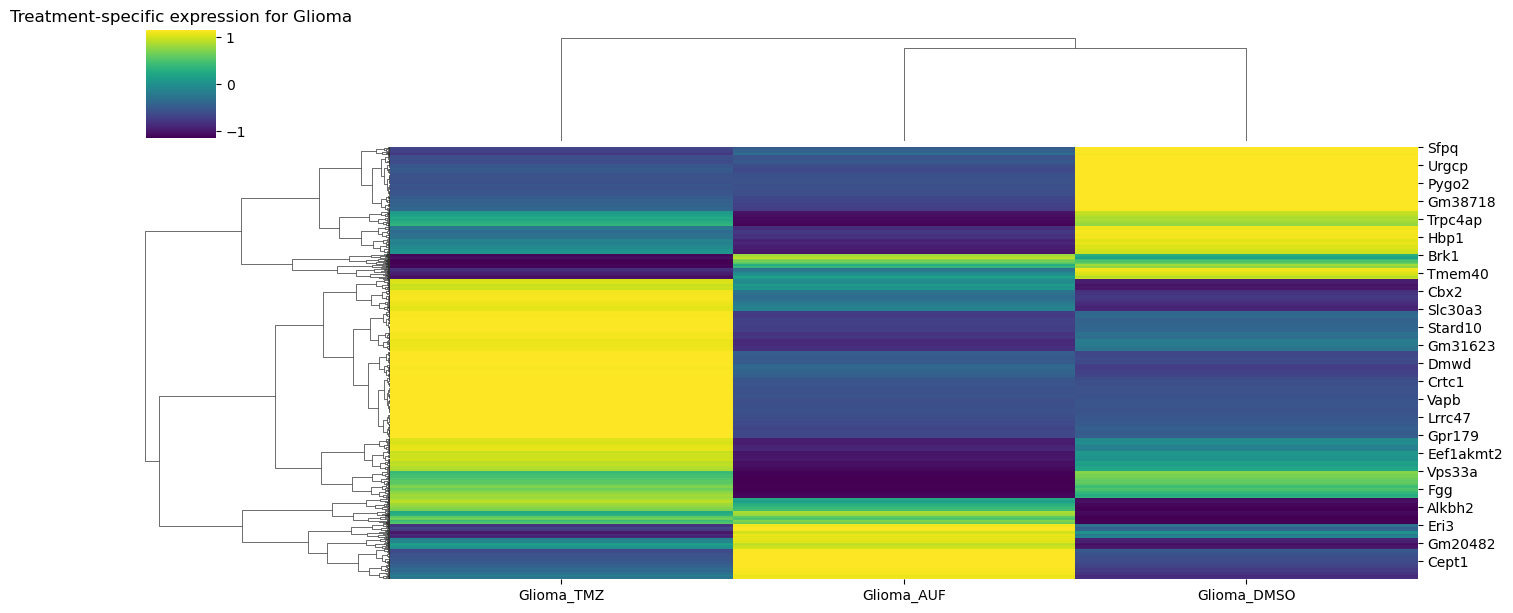

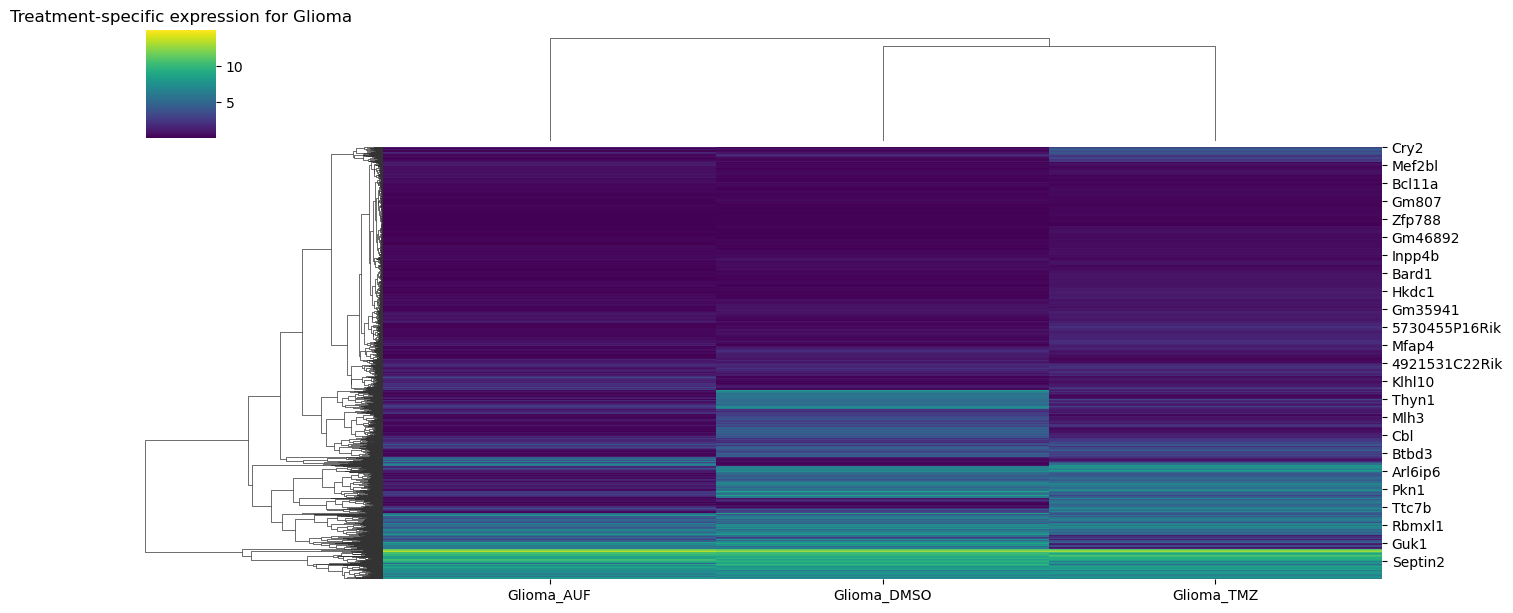

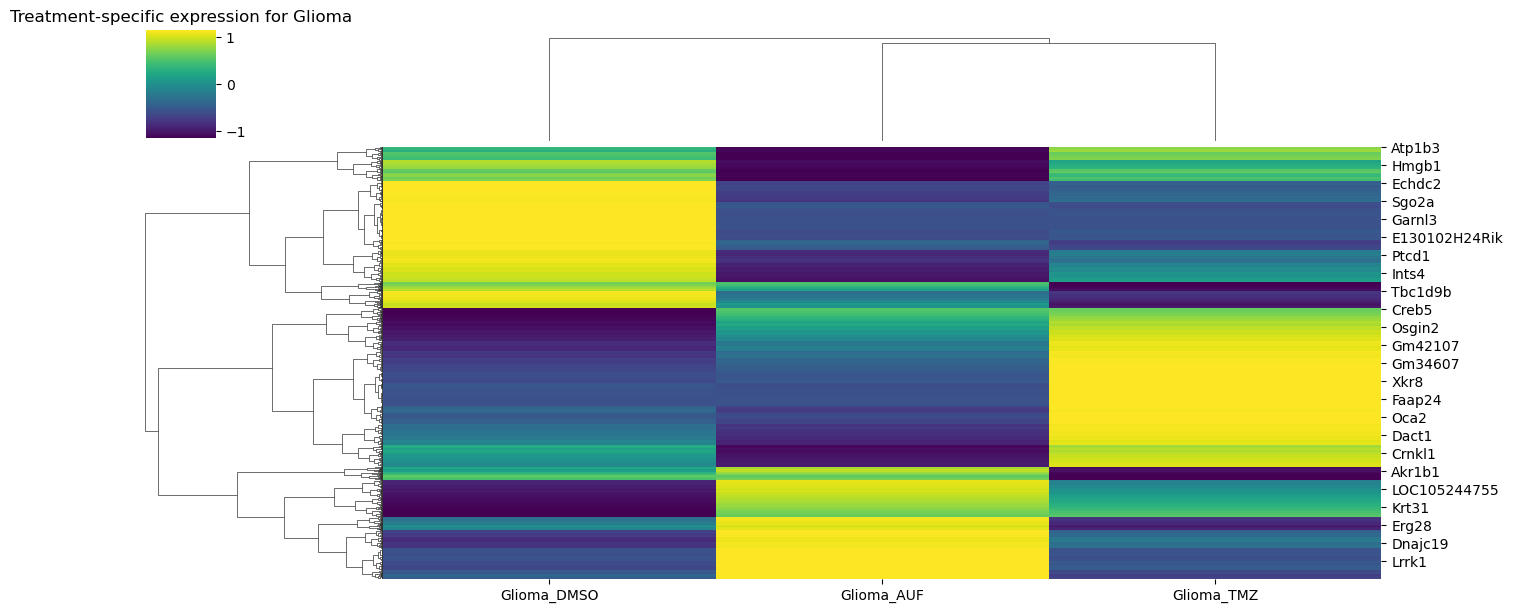

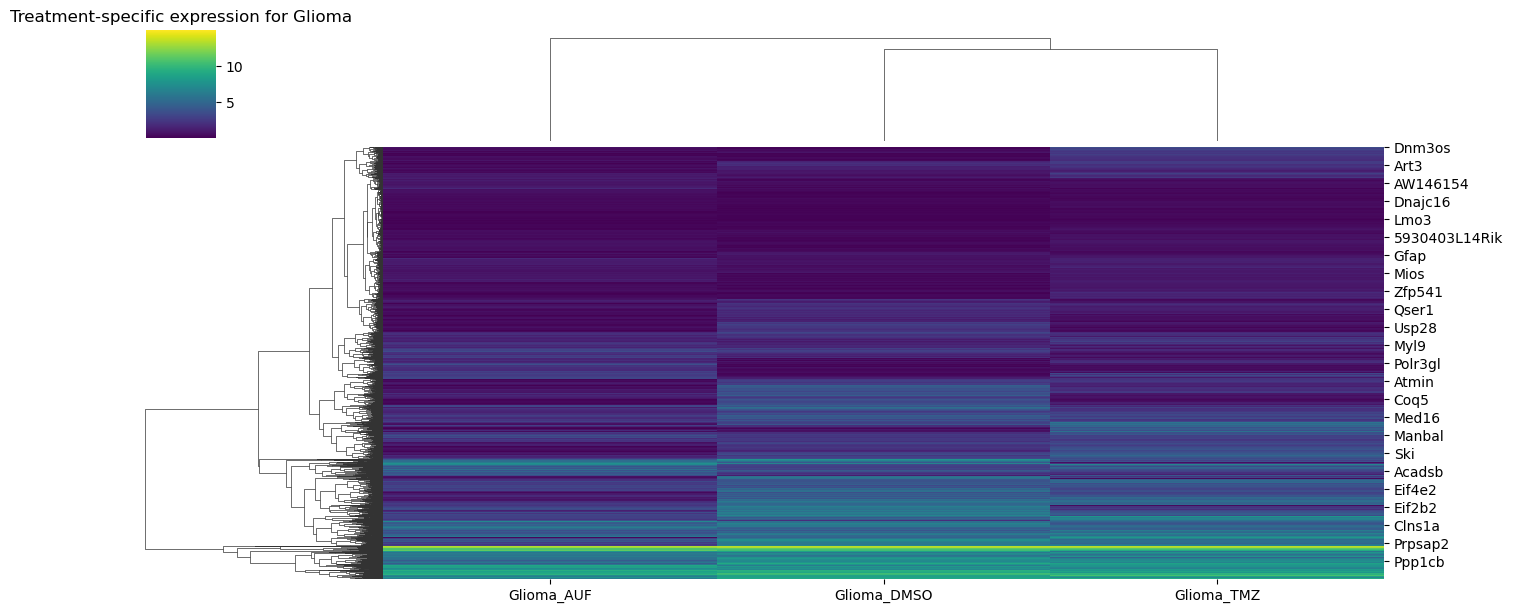

In [48]:
# Unfiltered data in (mRNAs only)
for origin in ['Healthy', 'Glioma']:
    clustermap_summarized_median(final_tpm, meta, origin, 'z-score')
    clustermap_summarized_median(final_log, meta, origin, None)
    clustermap_summarized(final_tpm, meta, origin, 'z-score')
    clustermap_summarized(final_log, meta, origin, None)